# Setting Up The Tools

Before we can start srawing our gauge, we need to bring in the right tools:
* **`matplotlib.pyplot`**: This is our main canvas and painting engine.
* **`Wedge` & `Polygon`**: These are specific shapes we're borrowing. We'll use `Wedge` to draw the curved, donut-like color segments, and `Polygon` to draw the pointy triangle for our needle.
* **`numpy`**: This is our math wizard. Since we're dealing with circles and angles, we need it to handle the trigonometry (like sines and cosines) to figure out exactly where to put our text and needle.

In [ ]:
# IMPORTING REQUIRED LIBRARIES
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge, Polygon
import numpy as np

# Making The Plots' Functions

**Drawing The Canvas & Background**

This cell is all about drawing the colorful arch and adding our labels.

First, we define our color palette (from green to red) and the size of our "donut" slices. Then, we use a loop to draw each slice one by one, moving from the left (180 degrees) over to the right (0 degrees).

Finally, we calculate the exact angles to place our "LOW", "MEDIUM", and "HIGH" text right above the segments, using the curved text function to wrap them nicely around the shape!

In [ ]:
# DRAW THE BACKGROUND
def draw_gauge_background(ax):
  # Colors
  colors = ['#5DB951', # Green
            '#A6C93F', # Light Green
            '#EDD82E', # Yellow
            '#F39A36', # Orange
            '#E4303C'] # Red

  # Rads
  r_outer = 1.0
  r_inner = 0.65

  # Angle (180 tp 0 degree)
  theta_start = 180
  theta_end = 0
  num_segments = len(colors)
  delta_theta = (theta_start - theta_end) / num_segments

  # Drawing color segments
  for i in range(num_segments):
    start_angle = theta_start - (i + 1) * delta_theta
    end_angle = theta_start - i * delta_theta

    # Wedge
    wedge = Wedge(
      center=(0, 0), r=r_outer, theta1=start_angle, theta2=end_angle,
      width=r_outer-r_inner, facecolor=colors[i], edgecolor='white', linewidth=3
    )
    ax.add_patch(wedge)

  # Text label positioning
  label_r = 1.08
  text_color = '#1E3250'

  # Low label
  angle_low = 180 - (delta_theta / 2)
  draw_curved_text(ax, 'LOW', label_r, angle_low, text_color, 16, 'light')

  # Medium label
  draw_curved_text(ax, 'MEDIUM', label_r, 90, text_color, 16, 'light')

  # High label
  angle_high = delta_theta / 2
  draw_curved_text(ax, 'HIGH', label_r, angle_high, text_color, 16, 'light')

In [ ]:
# DRAW LABEL
def draw_curved_text(ax, text, radius, center_angle, color, fontsize, fontweight):
  char_widths = {'I': 0.4, 'M': 1, 'W': 1.2, 'H': 0.9, ' ': 0.5}

  total_width = sum(char_widths.get(c, 0.8) for c in text)
  spread_factor = 4.5

  current_angle = center_angle + (total_width * spread_factor) / 2

  for i, char in enumerate(text):
    w = char_widths.get(char, 0.8)
    char_angle = current_angle - (w * spread_factor) / 2

    x = radius * np.cos(np.radians(char_angle))
    y = radius * np.sin(np.radians(char_angle))

    rotation = char_angle - 90

    ax.text(x, y, char, ha='center', va='center', rotation=rotation,
            color=color, fontsize=fontsize, fontweight=fontweight)
    current_angle -= w * spread_factor

In [ ]:
# DRAW THE NEEDLE
def draw_needle(ax, value):
  # Ensure value is clamped between 1 and 5 to prevent breaking the visual
  value = max(1, min(5, value))
  needle_angle = 180 - (value - 1) * 45

  rad_angle = np.radians(needle_angle)
  needle_length = 0.85
  needle_color = '#2A446B'

  # Draw circle in the center
  pivot_r = 0.1
  circle = plt.Circle((0, 0), pivot_r, color=needle_color, zorder=10)
  ax.add_patch(circle)

  # Draw the needle (triangle)
  base_width = 0.04
  nx1, ny1 = needle_length * np.cos(rad_angle), needle_length * np.sin(rad_angle) # Needle tip
  nx2, ny2 = base_width * np.cos(rad_angle + np.pi/2), base_width * np.sin(rad_angle + np.pi/2) # Left axis
  nx3, ny3 = base_width * np.cos(rad_angle - np.pi/2), base_width * np.sin(rad_angle - np.pi/2) # Right axis

  needle = Polygon([[nx1, ny1], [nx2, ny2], [nx3, ny3]], color=needle_color, zorder=9)
  ax.add_patch(needle)

# Showing The Plots

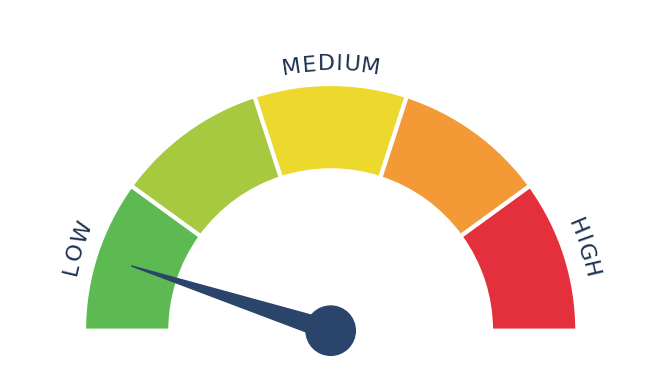

In [ ]:
# Figure and aspect ratio
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_aspect('equal')

draw_gauge_background(ax)

# Input value here: 1 (LOW) to 5 (HIGH)
# You can use decimals too, e.g., 3.5 will point directly between yellow and orange
draw_needle(ax, value=1.4)

# Add title
# Uncomment the following row to add title
# ax.set_title("CORTISOL LEVEL", fontsize=20, fontweight='light', pad=20)

# Clear axis
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.2, 1.3)
ax.axis('off')

# Show graphic
plt.tight_layout()
plt.show()

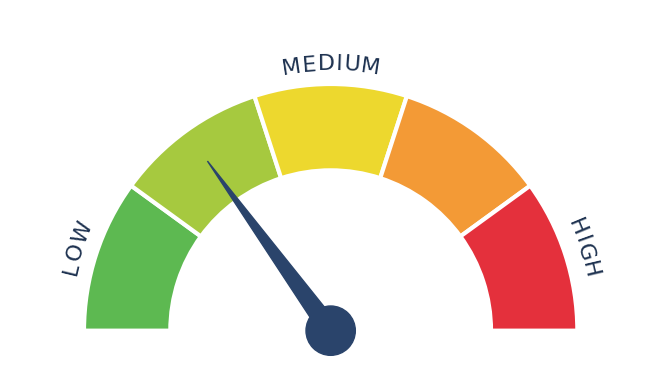

In [ ]:
# Figure and aspect ratio
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_aspect('equal')

draw_gauge_background(ax)

# Input value here: 1 (LOW) to 5 (HIGH)
# You can use decimals too, e.g., 3.5 will point directly between yellow and orange
draw_needle(ax, value=2.2)

# Add title
# Uncomment the following row to add title
# ax.set_title("CORTISOL LEVEL", fontsize=20, fontweight='light', pad=20)

# Clear axis
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.2, 1.3)
ax.axis('off')

# Show graphic
plt.tight_layout()
plt.show()

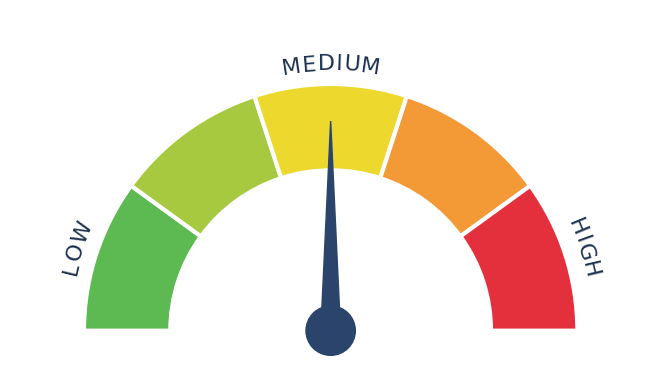

In [ ]:
# Figure and aspect ratio
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_aspect('equal')

draw_gauge_background(ax)

# Input value here: 1 (LOW) to 5 (HIGH)
# You can use decimals too, e.g., 3.5 will point directly between yellow and orange
draw_needle(ax, value=3)

# Add title
# Uncomment the following row to add title
# ax.set_title("CORTISOL LEVEL", fontsize=20, fontweight='light', pad=20)

# Clear axis
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.2, 1.3)
ax.axis('off')

# Show graphic
plt.tight_layout()
plt.show()

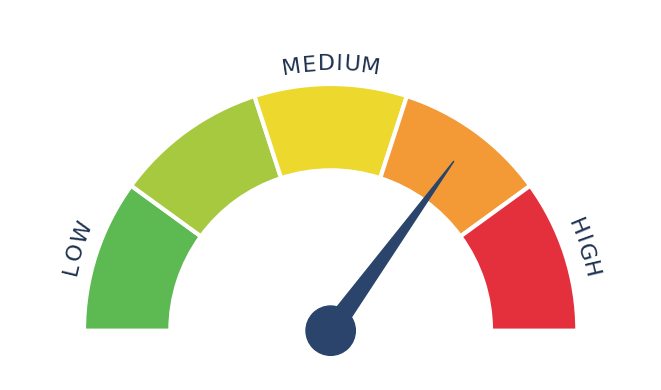

In [ ]:
# Figure and aspect ratio
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_aspect('equal')

draw_gauge_background(ax)

# Input value here: 1 (LOW) to 5 (HIGH)
# You can use decimals too, e.g., 3.5 will point directly between yellow and orange
draw_needle(ax, value=3.8)

# Add title
# Uncomment the following row to add title
# ax.set_title("CORTISOL LEVEL", fontsize=20, fontweight='light', pad=20)

# Clear axis
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.2, 1.3)
ax.axis('off')

# Show graphic
plt.tight_layout()
plt.show()

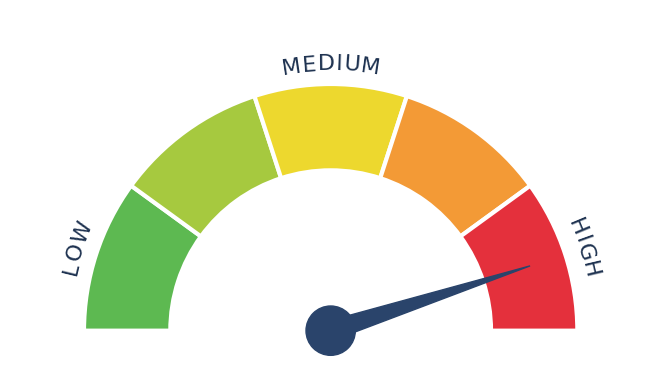

In [ ]:
# Figure and aspect ratio
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_aspect('equal')

draw_gauge_background(ax)

# Input value here: 1 (LOW) to 5 (HIGH)
# You can use decimals too, e.g., 3.5 will point directly between yellow and orange
draw_needle(ax, value=4.6)

# Add title
# Uncomment the following row to add title
# ax.set_title("CORTISOL LEVEL", fontsize=20, fontweight='light', pad=20)

# Clear axis
ax.set_xlim(-1.3, 1.3)
ax.set_ylim(-0.2, 1.3)
ax.axis('off')

# Show graphic
plt.tight_layout()
plt.show()